In [21]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [22]:
model_df = pd.read_csv(
    DATA_RAW/"fe_groups/g3.csv"
)

print(model_df.shape)
model_df.head()

(2255, 50)


,Unnamed: 0,tconst,primaryTitle,startYear,opening_weekend_gross,opening_theaters,domestic_release_date,release_type,all_domestic_release_types,distributor,...,actor_3_name,franchise,final_market_synopsis,g3_distance_from_nearest_seasonal_peak,g3_nearest_seasonal_peak_category,g3_nearby_general_movies_20d_count,g3_nearby_similar_genre_movies_20d_count,g3_nearby_general_similar_budget_movies_20d_count,g3_nearby_similar_genre_similar_budget_movies_20d_count,g3_budget_x_distance_from_peak
0,0,tt1311067,Halloween II,2009.0,7676836.0,1217.0,1981-10-30,Wide,Wide,Universal,...,Malcolm McDowell,Halloween,Laurie Strode struggles to come to terms with ...,3,halloween,0,0,0.0,0.0,7500000.0
1,1,tt0816462,Conan the Barbarian,2011.0,9479373.0,1358.0,1982-05-14,Wide,Wide,Universal,...,Rose McGowan,Conan,A horde of rampaging warriors massacre the par...,44,spring,0,0,0.0,0.0,880000000.0
2,2,tt4731008,The Wild Life,2016.0,4001400.0,1140.0,1984-09-28,Wide,Wide,NaN,...,Ilka Bessin,NaN,"Flight is the ultimate superpower, an extraord...",28,halloween,0,0,NaN,NaN,NaN
3,3,tt1160419,Dune: Part One,2021.0,6025091.0,915.0,1984-12-14,Wide,Wide,Universal,...,Zendaya,Dune,"Paul Atreides, a brilliant and gifted young ma...",6,christmas,0,0,0.0,0.0,270000000.0
4,4,tt1540128,Playing for Keeps,2012.0,1406300.0,1148.0,1986-10-03,Wide,Wide,Universal,...,Dennis Quaid,NaN,"A romantic comedy about a charming, down-on-hi...",24,halloween,0,0,0.0,0.0,840000000.0


In [23]:
target = "log_opening_weekend_gross"

g2_features = [
    'g3_distance_from_nearest_seasonal_peak',
    'g3_nearby_general_movies_20d_count',
    'g3_nearby_similar_genre_movies_20d_count',
    'g3_nearby_general_similar_budget_movies_20d_count',
    'g3_nearby_similar_genre_similar_budget_movies_20d_count',
    'g3_budget_x_distance_from_peak'
]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + g2_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
    "franchise",
    'g3_nearest_seasonal_peak_category'
] + people_features

In [24]:
model_df = model_df[
    model_df["franchise"].isna() |
    (model_df["franchise"].astype(str).str.strip() == "")
].copy()

In [25]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(1493, 26)
(1493,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
y_test_dollars = np.expm1(y_test)

In [28]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [29]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [30]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


{'model': 'Ridge Baseline',
 'r2_log': 0.46571423742144546,
 'mae_log': 0.8492595773696803,
 'mae_dollars': 7385994.3760667695}

In [31]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


{'model': 'XGBoost Baseline',
 'r2_log': 0.5013091686999145,
 'mae_log': 0.8108187859601228,
 'mae_dollars': 6257897.7424553195}

In [32]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.465714,0.849260,7.385994e+06
1,XGBoost Baseline,0.501309,0.810819,6.257898e+06


In [33]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [34]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


In [35]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

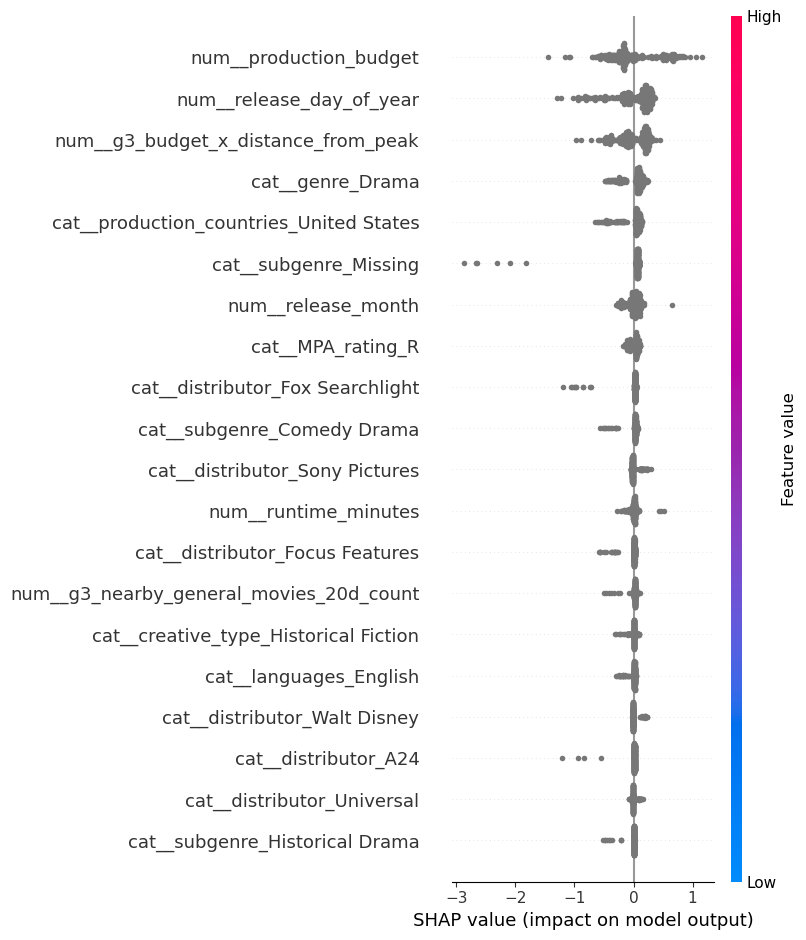

In [36]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

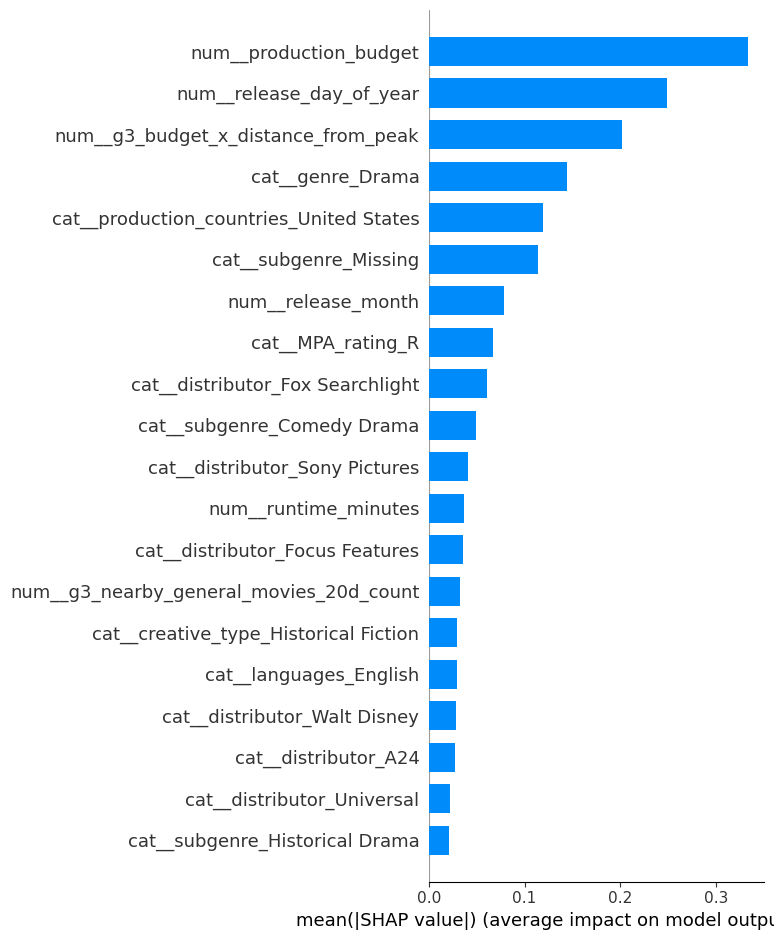

In [37]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [38]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g3_distance_from_nearest_seasonal_peak,g3_nearby_general_movies_20d_count,g3_nearby_similar_genre_movies_20d_count,g3_nearby_general_similar_budget_movies_20d_count,g3_nearby_similar_genre_similar_budget_movies_20d_count,g3_budget_x_distance_from_peak,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
39,25000000.0,127.0,2,56,34,14,2,6.0,1.0,8.500000e+08,...,nm0000154,nm0280179,nm0001029,nm0000899,nm0411581,18.244517,15.618675,83848082.0,6068822.0,77779260.0
1798,75000000.0,86.0,11,313,13,15,3,1.0,0.0,9.750000e+08,...,nm0155528,nm1942829,nm1212722,nm7372981,nm0429069,18.028717,16.794731,67572855.0,19672476.0,47900379.0
1795,55000000.0,134.0,11,306,6,15,2,5.0,1.0,3.300000e+08,...,nm0001741,nm0565026,nm1785339,nm2377903,nm3152605,17.748534,16.185457,51061119.0,10696821.0,40364298.0
1393,95000000.0,105.0,3,72,18,10,1,2.0,1.0,1.710000e+09,...,nm0000110,nm0919363,nm4141252,nm0000949,nm0534635,18.033213,17.139376,67877361.0,27767468.0,40109893.0
741,175000000.0,89.0,5,149,36,10,1,3.0,1.0,6.300000e+09,...,nm0230032,nm0677037,nm0000799,nm2973712,nm0001652,18.036617,17.206509,68108790.0,29695576.0,38413214.0
1396,130000000.0,94.0,3,86,4,8,1,4.0,1.0,5.200000e+08,...,nm7057993,nm8289285,nm8289285,NaN,NaN,17.768824,16.947599,52107731.0,22921808.0,29185923.0
1377,56200000.0,124.0,12,359,4,9,1,3.0,1.0,2.248000e+08,...,nm0551128,nm0487567,nm0447695,nm0000658,nm1517976,17.251171,15.363013,31051923.0,4699718.0,26352205.0
441,NaN,103.0,2,40,50,11,2,NaN,NaN,NaN,...,nm0005367,nm0000552,nm0000552,nm0628601,nm0187719,17.347603,16.088825,34195434.0,9711537.0,24483897.0
803,105000000.0,97.0,11,329,1,19,2,1.0,0.0,1.050000e+08,...,nm0166256,nm0166256,nm0741242,nm0202966,nm0001856,13.574955,17.016500,786190.0,24556828.0,23770638.0
340,52000000.0,106.0,6,153,32,14,0,2.0,0.0,1.664000e+09,...,nm0715636,nm1275670,nm0000098,nm0000681,nm0269463,17.483493,16.625931,39172785.0,16616899.0,22555886.0


In [39]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/results/g3_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/errors/g3_xgb_test_errors.csv",
    index=False
)